Trial 30 Complete [00h 02m 05s]
val_accuracy: 0.9787499904632568

Best val_accuracy So Far: 0.9787499904632568
Total elapsed time: 00h 23m 41s

Best Units: 448
Best Learning Rate: 0.001
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9331 - loss: 0.2262 - val_accuracy: 0.9645 - val_loss: 0.1209
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9729 - loss: 0.0906 - val_accuracy: 0.9732 - val_loss: 0.0882
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9828 - loss: 0.0562 - val_accuracy: 0.9760 - val_loss: 0.0843
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9868 - loss: 0.0406 - val_accuracy: 0.9774 - val_loss: 0.0765
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9904 - loss: 0.0301 - val_accuracy: 0.9783 - val_loss: 0.0788
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9927 - loss: 0.0225 - val_accuracy: 0.9704 - val_loss: 0.1030
Epoch 7/10
1500/1500 ━━━━━━━

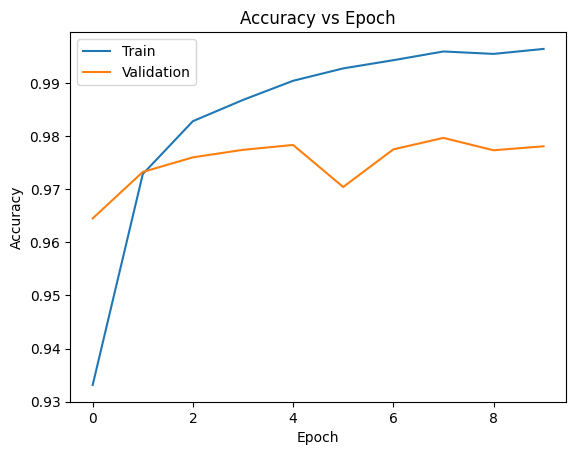

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


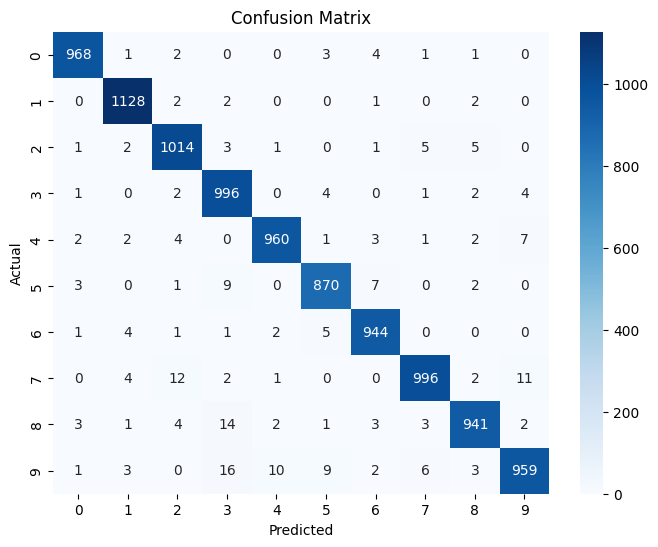

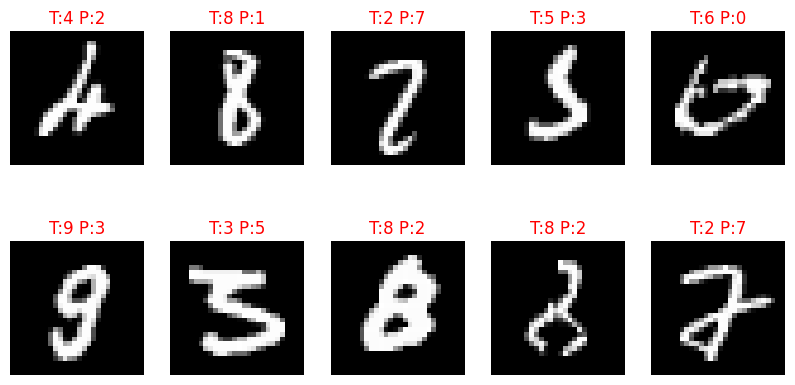

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


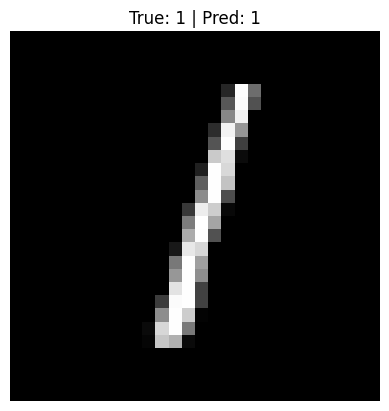

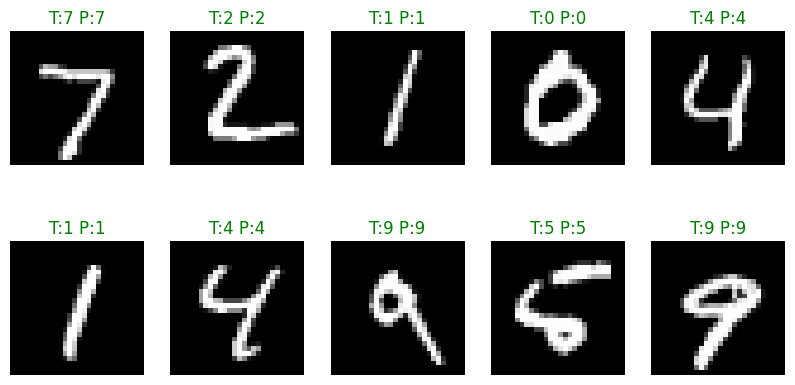

In [2]:
# ==========================================
# STEP 1: Install Required Library
# ==========================================
!pip install keras-tuner -q

# ==========================================
# STEP 2: Import Libraries
# ==========================================
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("TensorFlow Version:", tf.__version__)

# ==========================================
# STEP 3: Load Dataset (NO FILE NEEDED)
# ==========================================
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# ==========================================
# STEP 4: Model Builder (Same Logic)
# ==========================================
def model_builder(hp):
    model = keras.Sequential()

    model.add(keras.layers.Flatten(input_shape=(28, 28)))

    hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
    model.add(keras.layers.Dense(units=hp_units, activation='relu'))

    model.add(keras.layers.Dense(10, activation='softmax'))

    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==========================================
# STEP 5: Hyperparameter Tuning
# ==========================================
tuner = kt.Hyperband(
    model_builder,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='my_dir',
    project_name='mnist_tuning'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[stop_early]
)

# ==========================================
# STEP 6: Best Parameters
# ==========================================
best_hps = tuner.get_best_hyperparameters(1)[0]

print("\nBest Units:", best_hps.get('units'))
print("Best Learning Rate:", best_hps.get('learning_rate'))

# ==========================================
# STEP 7: Train Final Model
# ==========================================
model = tuner.hypermodel.build(best_hps)

history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2
)

# ==========================================
# STEP 8: Evaluation
# ==========================================
loss, acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", acc)

# ==========================================
# STEP 9: Accuracy Graph
# ==========================================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.title("Accuracy vs Epoch")
plt.show()

# ==========================================
# STEP 10: Confusion Matrix
# ==========================================
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ==========================================
# STEP 11: Misclassified Images
# ==========================================
errors = np.where(y_pred_classes != y_test)[0]

plt.figure(figsize=(10,5))
for i in range(10):
    idx = errors[i]
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"T:{y_test[idx]} P:{y_pred_classes[idx]}", color='red')
    plt.axis('off')

plt.show()

# ==========================================
# STEP 12: Random Prediction
# ==========================================
idx = np.random.randint(0, len(x_test))
img = x_test[idx]

pred = model.predict(img.reshape(1,28,28))
label = np.argmax(pred)

plt.imshow(img, cmap='gray')
plt.title(f"True: {y_test[idx]} | Pred: {label}")
plt.axis('off')
plt.show()

# ==========================================
# STEP 13: Correct Predictions
# ==========================================
correct = np.where(y_pred_classes == y_test)[0]

plt.figure(figsize=(10,5))
for i in range(10):
    idx = correct[i]
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"T:{y_test[idx]} P:{y_pred_classes[idx]}", color='green')
    plt.axis('off')

plt.show()